# ABSA Project — Results Overview

This notebook loads all saved result files from `results/` and displays the key tables and charts for the project.
No re-training is needed — all results are pre-computed.

**Sections:**
1. Model comparison table (Table 1)
2. Per-class F1 heatmap
3. Error taxonomy breakdown
4. Intervention comparison
5. Sample error cases

In [13]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'results') if os.path.basename(os.getcwd()) == 'notebooks' else 'results'

def load(fname):
    with open(os.path.join(RESULTS_DIR, fname)) as f:
        return json.load(f)

baselines   = load('baselines.json')
bert        = load('bert.json')
interventions = load('interventions.json')
llm         = load('llm_local.json')
errors      = load('errors.json')

print('Results loaded successfully.')

Results loaded successfully.


## 1. Model Comparison Table (Table 1)

In [14]:
rows = []

baseline_display = {
    'majority_class': 'Majority class',
    'nbow':           'NBOW',
    'tfidf_lr':       'TF-IDF + LR',
    'vader':          'VADER',
}
for key, name in baseline_display.items():
    m = baselines[key]
    pcf = m.get('per_class_f1', {})
    rows.append({
        'Model': name,
        'Accuracy': m['accuracy'],
        'Macro-F1': m['macro_f1'],
        'Pos F1':   pcf.get('positive', 0),
        'Neg F1':   pcf.get('negative', 0),
        'Neu F1':   pcf.get('neutral', 0),
        'Con F1':   pcf.get('conflict', 0),
    })

rows.append({
    'Model': 'BERT-base fine-tuned',
    'Accuracy': bert['accuracy'],
    'Macro-F1': bert['macro_f1'],
    'Pos F1':   bert['per_class_f1'].get('positive', 0),
    'Neg F1':   bert['per_class_f1'].get('negative', 0),
    'Neu F1':   bert['per_class_f1'].get('neutral', 0),
    'Con F1':   bert['per_class_f1'].get('conflict', 0),
})

intervention_display = {
    'negation':           'BERT + Negation marking',
    'conflict_oversample':'BERT + Conflict oversample',
    'decompose':          'BERT + Decomposition',
    'combined':           'BERT + Combined',
}
for key, name in intervention_display.items():
    m = interventions[key]
    pcf = m.get('per_class_f1', {})
    rows.append({
        'Model': name,
        'Accuracy': m['accuracy'],
        'Macro-F1': m['macro_f1'],
        'Pos F1':   pcf.get('positive', 0),
        'Neg F1':   pcf.get('negative', 0),
        'Neu F1':   pcf.get('neutral', 0),
        'Con F1':   pcf.get('conflict', 0),
    })

rows.append({
    'Model': 'BART-large-mnli (zero-shot)',
    'Accuracy': llm['accuracy'],
    'Macro-F1': llm['macro_f1'],
    'Pos F1':   llm['per_class_f1'].get('positive', 0),
    'Neg F1':   llm['per_class_f1'].get('negative', 0),
    'Neu F1':   llm['per_class_f1'].get('neutral', 0),
    'Con F1':   llm['per_class_f1'].get('conflict', 0),
})

df = pd.DataFrame(rows)
for col in ['Accuracy', 'Macro-F1', 'Pos F1', 'Neg F1', 'Neu F1', 'Con F1']:
    df[col] = df[col].map('{:.3f}'.format)

df.index = range(1, len(df)+1)
display(df)

,Model,Accuracy,Macro-F1,Pos F1,Neg F1,Neu F1,Con F1
1,Majority class,0.586,0.185,0.739,0.000,0.000,0.000
2,NBOW,0.698,0.424,0.819,0.521,0.356,0.000
3,TF-IDF + LR,0.706,0.531,0.841,0.587,0.492,0.205
4,VADER,0.644,0.411,0.790,0.471,0.382,0.000
5,BERT-base fine-tuned,0.770,0.525,0.876,0.693,0.530,0.000
6,BERT + Negation marking,0.771,0.520,0.885,0.681,0.512,0.000
7,BERT + Conflict oversample,0.773,0.602,0.881,0.715,0.488,0.326
8,BERT + Decomposition,0.773,0.521,0.887,0.696,0.500,0.000
9,BERT + Combined,0.765,0.606,0.887,0.688,0.423,0.426
10,BART-large-mnli (zero-shot),0.721,0.439,0.864,0.680,0.178,0.035


## 2. Per-Class F1 Heatmap

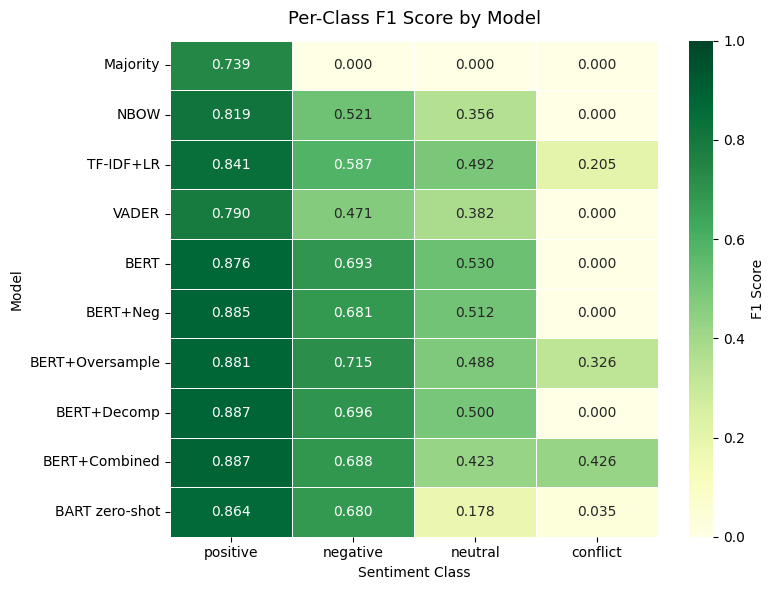

In [15]:
model_names = [
    'Majority', 'NBOW', 'TF-IDF+LR', 'VADER',
    'BERT', 'BERT+Neg', 'BERT+Oversample', 'BERT+Decomp', 'BERT+Combined',
    'BART zero-shot'
]

all_results = (
    [baselines[k] for k in ['majority_class', 'nbow', 'tfidf_lr', 'vader']]
    + [bert]
    + [interventions[k] for k in ['negation', 'conflict_oversample', 'decompose', 'combined']]
    + [llm]
)

classes = ['positive', 'negative', 'neutral', 'conflict']
heat_data = []
for r in all_results:
    pcf = r.get('per_class_f1', {})
    heat_data.append([pcf.get(c, 0) for c in classes])

heat_df = pd.DataFrame(heat_data, index=model_names, columns=classes)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score by Model', fontsize=13, pad=12)
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'per_class_f1_heatmap.png'), dpi=150)
plt.show()

## 3. Macro-F1 Bar Chart

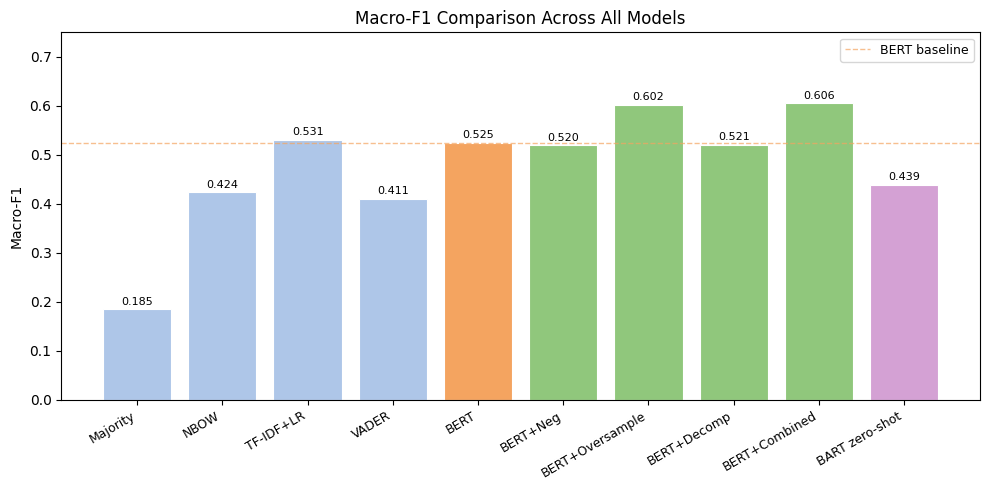

In [16]:
macro_f1s = [r['macro_f1'] for r in all_results]
colors = ['#aec6e8'] * 4 + ['#f4a460'] + ['#90c77c'] * 4 + ['#d4a1d4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, macro_f1s, color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Macro-F1')
ax.set_title('Macro-F1 Comparison Across All Models')
ax.axhline(y=macro_f1s[4], color='#f4a460', linestyle='--', linewidth=1, alpha=0.7, label='BERT baseline')
for bar, val in zip(bars, macro_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'macro_f1_comparison.png'), dpi=150)
plt.show()

## 4. Error Taxonomy Breakdown

Total test examples : 739
Total errors        : 170
Error rate          : 23.0%



,Category,Count,Percentage
0,implicit,104,61.2%
1,negation,32,18.8%
2,conflict_class,18,10.6%
3,multi_aspect,8,4.7%
4,other,8,4.7%
5,boundary,0,0.0%


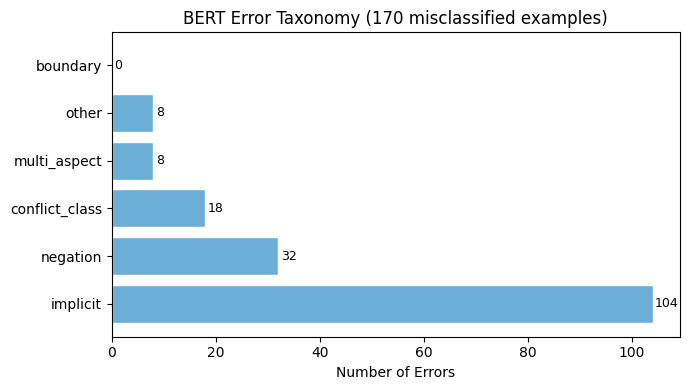

In [17]:
cat_counts = errors['category_counts']
cat_pct    = errors['category_pct']

err_df = pd.DataFrame({
    'Category':    list(cat_counts.keys()),
    'Count':       list(cat_counts.values()),
    'Percentage':  [f"{v*100:.1f}%" for v in cat_pct.values()],
})
print(f"Total test examples : {errors['total_examples']}")
print(f"Total errors        : {errors['total_errors']}")
print(f"Error rate          : {errors['error_rate']*100:.1f}%\n")
display(err_df.sort_values('Count', ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, 4))
sorted_items = sorted(cat_counts.items(), key=lambda x: -x[1])
cats, counts = zip(*sorted_items)
ax.barh(cats, counts, color='#6baed6', edgecolor='white')
ax.set_xlabel('Number of Errors')
ax.set_title('BERT Error Taxonomy (170 misclassified examples)')
for i, (cat, cnt) in enumerate(zip(cats, counts)):
    ax.text(cnt + 0.5, i, str(cnt), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'error_taxonomy.png'), dpi=150)
plt.show()

## 5. Intervention Results

,Model,Accuracy,Macro-F1,Conflict F1
1,BERT (base),0.770,0.525,0.000
2,Negation,0.771,0.520,0.000
3,Conflict oversample,0.773,0.602,0.326
4,Decomposition,0.773,0.521,0.000
5,Combined,0.765,0.606,0.426


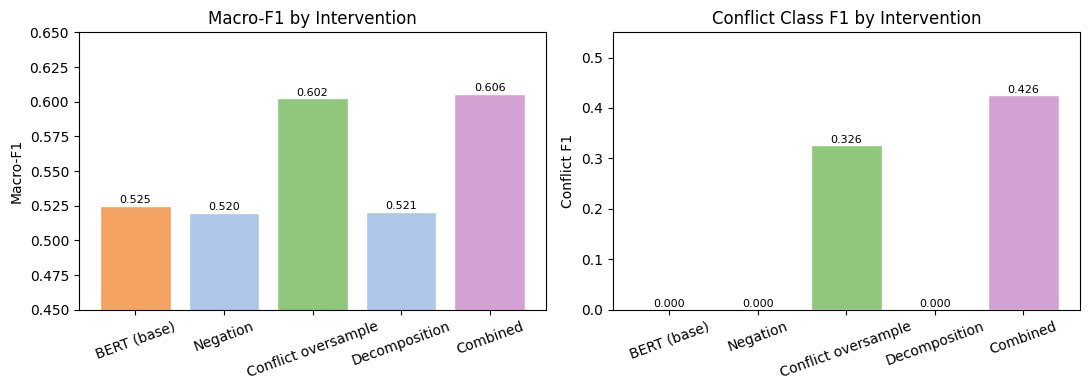

In [18]:
int_names  = ['BERT (base)', 'Negation', 'Conflict oversample', 'Decomposition', 'Combined']
int_results = [bert] + [interventions[k] for k in ['negation', 'conflict_oversample', 'decompose', 'combined']]

int_df = pd.DataFrame({
    'Model':         int_names,
    'Accuracy':      [f"{r['accuracy']:.3f}" for r in int_results],
    'Macro-F1':      [f"{r['macro_f1']:.3f}" for r in int_results],
    'Conflict F1':   [f"{r.get('per_class_f1', {}).get('conflict', 0):.3f}" for r in int_results],
})
int_df.index = range(1, len(int_df)+1)
display(int_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
macro_vals   = [r['macro_f1'] for r in int_results]
conflict_vals = [r.get('per_class_f1', {}).get('conflict', 0) for r in int_results]
colors_int = ['#f4a460', '#aec6e8', '#90c77c', '#aec6e8', '#d4a1d4']

axes[0].bar(int_names, macro_vals, color=colors_int, edgecolor='white')
axes[0].set_title('Macro-F1 by Intervention')
axes[0].set_ylim(0.45, 0.65)
axes[0].set_ylabel('Macro-F1')
for i, v in enumerate(macro_vals):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(int_names, conflict_vals, color=colors_int, edgecolor='white')
axes[1].set_title('Conflict Class F1 by Intervention')
axes[1].set_ylim(0, 0.55)
axes[1].set_ylabel('Conflict F1')
for i, v in enumerate(conflict_vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'interventions.png'), dpi=150)
plt.show()

## 6. Sample Error Cases

In [19]:
id_to_label = {0: 'positive', 1: 'negative', 2: 'neutral', 3: 'conflict'}

sample_errors = errors.get('errors', [])
if sample_errors:
    sample_df = pd.DataFrame(sample_errors[:20])[['text', 'aspect', 'true_label', 'pred_label', 'category']]
    sample_df['true_label'] = sample_df['true_label'].map(id_to_label)
    sample_df['pred_label'] = sample_df['pred_label'].map(id_to_label)
    sample_df.columns = ['Text', 'Aspect', 'True', 'Predicted', 'Error Category']
    sample_df.index = range(1, len(sample_df)+1)
    display(sample_df)
else:
    print('No per-example error data available.')

,Text,Aspect,True,Predicted,Error Category
1,Ummm...the beer was cold.,beer,positive,negative,implicit
2,Delicious food at a great price but do not go ...,front door,neutral,positive,implicit
3,"Great wine selection, Gigondas is worth the pr...",price,neutral,positive,implicit
4,I recommend getting a reservation even though ...,reservation,neutral,negative,implicit
5,"(food was delivered by a busboy, not waiter) W...",meal,neutral,negative,implicit
6,Just don't take the seat between the bar and t...,seat,negative,neutral,implicit
7,"Outstanding Bagels, but you get what you pay for.",Bagels,positive,neutral,multi_aspect
8,If your favorite Chinese food is General Tao c...,General Tao chicken,negative,neutral,negation
9,"Saul is pretty good, but definitely not great.",Saul,neutral,negative,negation
10,And they have these home made potato chips at ...,bar,neutral,positive,implicit
